<a href="https://colab.research.google.com/github/dharshinikumaravel2004-byte/INTERNSHIP-DL/blob/main/kl_divergence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install imblearn

In [ ]:
!pip install seaborn

In [ ]:
!pip install -U tensorflow scikeras imbalanced-learn

In [ ]:
!pip install scikeras

In [ ]:
# ================================
# 1. Importing Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef

from imblearn.over_sampling import SMOTE

from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical

from scikeras.wrappers import KerasClassifier

import warnings
warnings.filterwarnings("ignore")


In [ ]:
TRAIN_PATH = "/content/drive/MyDrive/mit dataset/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/mit dataset/mitbih_test.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (87554, 188)
Test shape: (21892, 188)


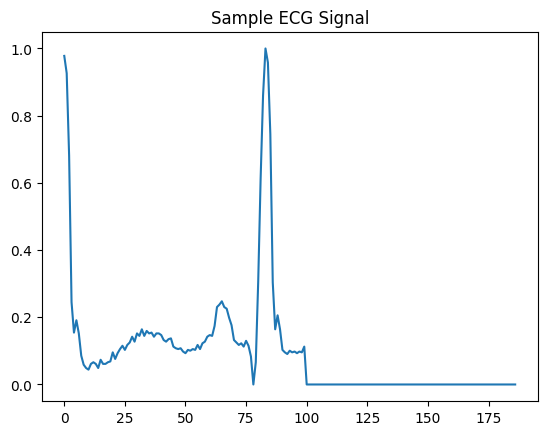

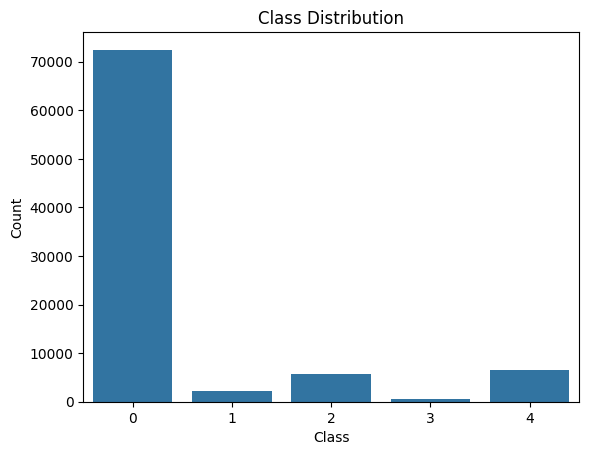

In [ ]:
# Plot one ECG signal
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

# Class distribution
counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()


In [ ]:
X = train.iloc[:, :-1]   # 187 features
y = train.iloc[:, -1]    # class label


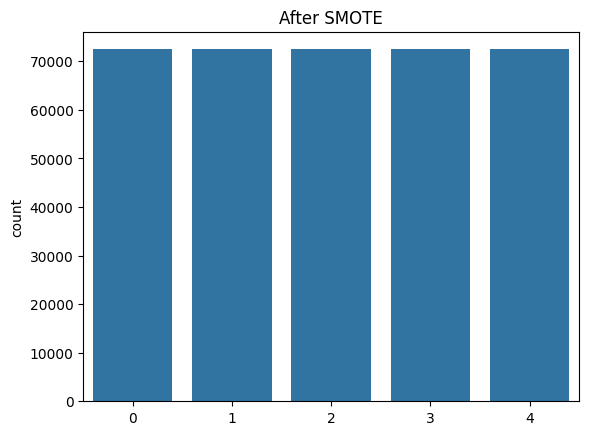

In [ ]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

sns.barplot(x=classes, y=y_res.value_counts().sort_index())
plt.title("After SMOTE")
plt.show()


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)


In [ ]:
num_classes = 5

y_train_oh = to_categorical(y_train, num_classes)
y_val_oh   = to_categorical(y_val, num_classes)


In [ ]:
X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

y_test_oh = to_categorical(y_test, num_classes)


In [ ]:
def ann_model():
    model = Sequential()
    model.add(Dense(50, input_shape=(187,), activation='relu'))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(5, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='kullback_leibler_divergence',
        metrics=['accuracy']
    )
    return model


In [ ]:
from keras.losses import KLDivergence


In [ ]:
def ann_model():
    model = Sequential()
    model.add(Dense(50, input_shape=(187,), activation='relu'))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(5, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss=KLDivergence(),
        metrics=['accuracy']
    )
    return model


In [ ]:
model = ann_model()

history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=10,
    batch_size=64
)


Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8141 - loss: 0.5196 - val_accuracy: 0.9255 - val_loss: 0.2080
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9292 - loss: 0.2011 - val_accuracy: 0.9462 - val_loss: 0.1543
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9488 - loss: 0.1487 - val_accuracy: 0.9577 - val_loss: 0.1221
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.9585 - loss: 0.1222 - val_accuracy: 0.9625 - val_loss: 0.1090
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9648 - loss: 0.1043 - val_accuracy: 0.9689 - val_loss: 0.0934
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9700 - loss: 0.0908 - val_accuracy: 0.9704 - val_loss: 0.0844
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9726 - loss: 0.0816 - val_accuracy: 0.9752 - val_loss: 0.0727
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9756 - loss: 0

In [ ]:
y_train_oh.shape[1] == 5


True

In [ ]:
y_val_pred = np.argmax(model.predict(X_val), axis=1)
mcc = matthews_corrcoef(y_val, y_val_pred)

print("Validation MCC:", mcc)


2265/2265 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Validation MCC: 0.9736039704576934


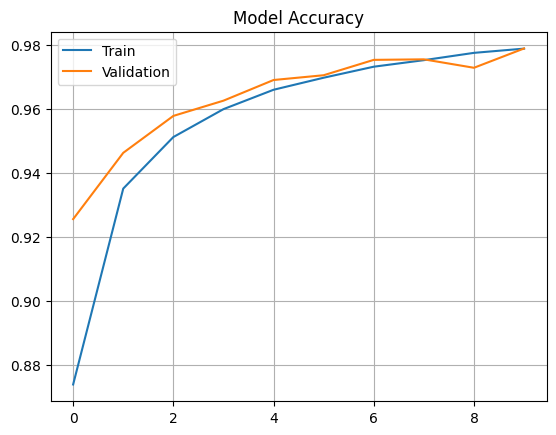

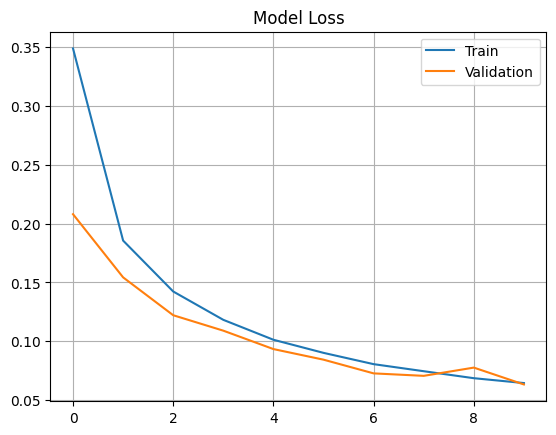

In [ ]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Model Accuracy")
plt.legend()
plt.grid()
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Model Loss")
plt.legend()
plt.grid()
plt.show()


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_oh)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)


685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9336 - loss: 0.1998
Test Accuracy: 0.9324410557746887
Test Loss: 0.21991288661956787


685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.93      0.96     18118
         1.0       0.35      0.83      0.49       556
         2.0       0.85      0.93      0.89      1448
         3.0       0.42      0.85      0.57       162
         4.0       0.96      0.98      0.97      1608

    accuracy                           0.93     21892
   macro avg       0.72      0.90      0.78     21892
weighted avg       0.96      0.93      0.94     21892



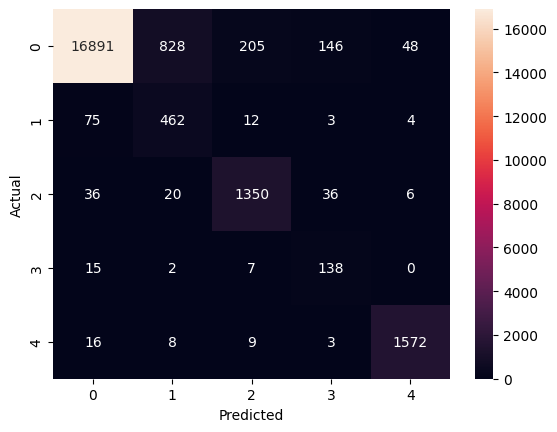

In [ ]:
y_test_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
kfold = KFold(n_splits=4, shuffle=True, random_state=42)
fold = 1
acc_scores = []

for train_idx, val_idx in kfold.split(X_train):
    print(f"\nFold {fold}")

    X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_va = y_train_oh[train_idx], y_train_oh[val_idx]

    model = ann_model()
    model.fit(
        X_tr, y_tr,
        epochs=10,
        batch_size=64,
        verbose=0
    )

    y_va_pred = np.argmax(model.predict(X_va), axis=1)
    y_va_true = np.argmax(y_va, axis=1)
    acc = accuracy_score(y_va_true, y_va_pred)
    acc_scores.append(acc)
    print("Accuracy:", acc)
    fold += 1



Fold 1
2265/2265 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Accuracy: 0.9779498006098991

Fold 2
2265/2265 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Accuracy: 0.9772874667108222

Fold 3
2265/2265 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Accuracy: 0.978929502835617

Fold 4
2265/2265 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Accuracy: 0.9813304632197707


In [ ]:
print("\nCross-validation accuracies:", acc_scores)
print("Mean CV accuracy:", np.mean(acc_scores))



Cross-validation accuracies: [0.9779498006098991, 0.9772874667108222, 0.978929502835617, 0.9813304632197707]
Mean CV accuracy: 0.9788743083440273


In [ ]:
y_val_pred = np.argmax(model.predict(X_val), axis=1)
mcc = matthews_corrcoef(y_val, y_val_pred)

print("Validation MCC:", mcc)


2265/2265 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Validation MCC: 0.9761833582792486


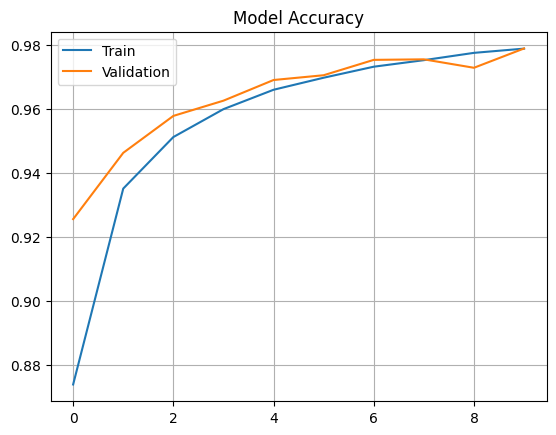

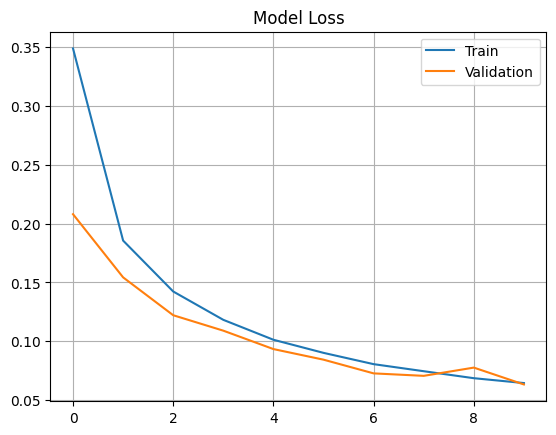

In [ ]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Model Accuracy")
plt.legend()
plt.grid()
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Model Loss")
plt.legend()
plt.grid()
plt.show()


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_oh)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)


685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9555 - loss: 0.1405
Test Accuracy: 0.9490681290626526
Test Loss: 0.17446058988571167


In [ ]:
train.head()


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
test.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,1.000000,0.758264,0.111570,0.000000,0.080579,0.078512,0.066116,0.049587,0.047521,0.035124,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.908425,0.783883,0.531136,0.362637,0.366300,0.344322,0.333333,0.307692,0.296703,0.300366,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.730088,0.212389,0.000000,0.119469,0.101770,0.101770,0.110619,0.123894,0.115044,0.132743,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.000000,0.910417,0.681250,0.472917,0.229167,0.068750,0.000000,0.004167,0.014583,0.054167,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.570470,0.399329,0.238255,0.147651,0.000000,0.003356,0.040268,0.080537,0.070470,0.090604,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
train.isna().sum()

,0
0,0
1,0
2,0
3,0
4,0
...,...
183,0
184,0
185,0
186,0


In [ ]:
test.isna().sum()


,0
0,0
1,0
2,0
3,0
4,0
...,...
183,0
184,0
185,0
186,0


685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.95      0.97     18118
         1.0       0.44      0.81      0.57       556
         2.0       0.87      0.92      0.90      1448
         3.0       0.56      0.84      0.67       162
         4.0       0.96      0.98      0.97      1608

    accuracy                           0.95     21892
   macro avg       0.77      0.90      0.82     21892
weighted avg       0.96      0.95      0.95     21892



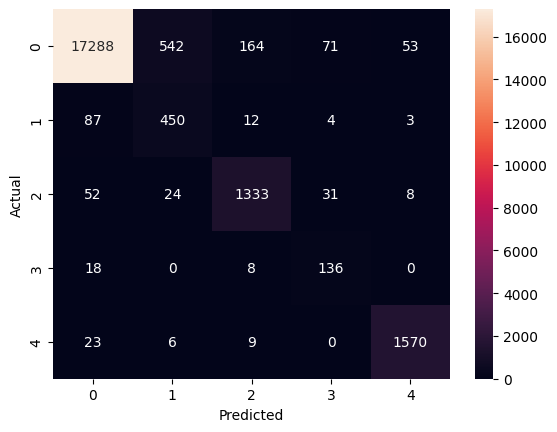

In [ ]:
y_test_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
import numpy as np

kfold = KFold(n_splits=4, shuffle=True, random_state=42)

acc_scores = []
fold = 1

for train_idx, val_idx in kfold.split(X_train):
    print(f"\nFold {fold}")

    X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_va = y_train_oh[train_idx], y_train_oh[val_idx]

    model = ann_model()
    model.fit(X_tr, y_tr, epochs=10, batch_size=64, verbose=0)

    y_pred = np.argmax(model.predict(X_va), axis=1)
    y_true = np.argmax(y_va, axis=1)

    acc = accuracy_score(y_true, y_pred)
    acc_scores.append(acc)

    print("Accuracy:", acc)
    fold += 1

print("\nCV Accuracies:", acc_scores)
print("Mean CV Accuracy:", np.mean(acc_scores))



Fold 1
2265/2265 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Accuracy: 0.9753280622593865

Fold 2
2265/2265 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Accuracy: 0.9736722275116944

Fold 3
2265/2265 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Accuracy: 0.9741413806902072

Fold 4
2265/2265 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Accuracy: 0.9792054752935657

CV Accuracies: [0.9753280622593865, 0.9736722275116944, 0.9741413806902072, 0.9792054752935657]
Mean CV Accuracy: 0.9755867864387134


In [ ]:
cv_results = pd.DataFrame({
    "Fold": [1, 2, 3, 4],
    "Accuracy": acc_scores
})

cv_results.loc["Mean"] = ["—", np.mean(acc_scores)]
cv_results


,Fold,Accuracy
0,1,0.975328
1,2,0.973672
2,3,0.974141
3,4,0.979205
Mean,—,0.975587
